In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
# itos

In [47]:
# Build the dataset

block_size = 3 # context length
X, Y = [], []

for word in words:
# for word in words[:5]:
    context = [0]*block_size
    for ch in word+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]
    
X = torch.tensor(X)
Y = torch.tensor(Y)

In [48]:
X.shape,X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

### 1st Layer
- Contains 3 linear layers, each for one character of the context

In [7]:
# Weight Matrix, embedding dimension = 2 for all the 27 vocabs
C = torch.randn((27,2))

In [8]:
C[5]

tensor([-0.5085,  0.0373])

In [9]:
C[X]

tensor([[[-0.2448, -0.9318],
         [-0.2448, -0.9318],
         [-0.2448, -0.9318]],

        [[-0.2448, -0.9318],
         [-0.2448, -0.9318],
         [-0.5085,  0.0373]],

        [[-0.2448, -0.9318],
         [-0.5085,  0.0373],
         [ 1.3621, -0.2703]],

        [[-0.5085,  0.0373],
         [ 1.3621, -0.2703],
         [ 1.3621, -0.2703]],

        [[ 1.3621, -0.2703],
         [ 1.3621, -0.2703],
         [ 1.6077, -0.5160]],

        [[-0.2448, -0.9318],
         [-0.2448, -0.9318],
         [-0.2448, -0.9318]],

        [[-0.2448, -0.9318],
         [-0.2448, -0.9318],
         [-1.0485,  0.8257]],

        [[-0.2448, -0.9318],
         [-1.0485,  0.8257],
         [-1.3278, -0.8854]],

        [[-1.0485,  0.8257],
         [-1.3278, -0.8854],
         [ 0.5739, -1.2553]],

        [[-1.3278, -0.8854],
         [ 0.5739, -1.2553],
         [-0.1980,  1.1826]],

        [[ 0.5739, -1.2553],
         [-0.1980,  1.1826],
         [ 0.5739, -1.2553]],

        [[-0.1980,  1

In [10]:
C[X].shape

torch.Size([32, 3, 2])

In [11]:
C[X][13,2]

tensor([ 1.6077, -0.5160])

In [12]:
X[13,2]

tensor(1)

In [13]:
C[1]

tensor([ 1.6077, -0.5160])

- `C[1]` is equal to `C[X][13,2]` as `X[13,2] = 1`

In [14]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

### Hidden Layer

In [15]:
W1 = torch.randn((6,100)) # 6 = block_size(3) * emb_size(2)
b1 = torch.randn(100)

In [16]:
emb @ W1 + b1 # Produces error

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [ ]:
a = torch.zeros((3,2))
a.storage() # 6 consecutive memory locations

 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

In [ ]:
emb.view(32,6) @ W1 + b1 # we can do this using cat and unbind, but view is more efficient cz it doesn't perform any operation on memory
# In memory, tensors are always stored in a contiguous block of memory, so view is just a way to change how the tensor is interpreted

tensor([[ 1.3399,  0.6979,  2.3475,  ..., -0.1763, -1.1467, -0.8060],
        [ 0.3001,  1.6995,  1.4178,  ...,  0.0835, -1.5746,  0.0485],
        [ 0.2026, -1.3293,  0.1938,  ..., -2.1824, -1.9037, -1.5775],
        ...,
        [-2.5045, -3.8251,  0.7770,  ..., -2.6932, -3.5297, -1.8583],
        [-2.8588, -2.4015,  2.6510,  ..., -0.7964, -3.5756, -2.4678],
        [-0.9588, -3.2322,  0.6665,  ..., -3.9291, -1.3798, -3.7419]])

In [25]:
# Hidden layer has tanh activation
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # -1 means infer the size from the other dimensions,same as 32 in this case
h.shape

torch.Size([32, 100])

In [ ]:
h[:1] # All between -1 and 1 bcz of tanh

tensor([[ 0.8716,  0.6030,  0.9819, -0.8527, -0.9165, -0.9351, -0.9928,  0.7175,
          0.0690, -0.9827,  0.8259,  0.9499, -0.7144, -0.9983, -0.1665,  0.6719,
         -0.9994, -0.9953,  0.9143,  0.9993, -0.2512,  0.6884,  0.8127,  0.2400,
         -0.5100,  0.2554,  0.9987,  0.9708, -0.1862,  0.9778,  0.8801,  0.5511,
          0.9774,  0.9994,  0.9469,  0.4226, -0.8831,  0.9883, -0.8437, -0.8899,
         -0.9936, -0.1554,  0.5037, -0.7639, -0.8271,  0.9632,  0.8813, -0.1619,
         -0.4875,  0.9387,  0.2959,  0.6120, -0.3989, -0.8960,  0.8468, -0.9325,
         -0.9995, -0.9138,  0.9081,  0.9545, -0.5655, -0.9989, -0.9381, -0.9341,
          0.8495,  1.0000, -0.8737, -0.8437, -0.8930,  0.9368, -0.5421,  0.9883,
          0.9886, -0.0838, -0.0752,  0.9695, -0.7606, -0.7553,  0.6898, -0.9613,
          0.0757, -0.7492,  0.8872, -0.9190,  0.1592, -0.8960, -0.9711,  0.9855,
          0.9970, -0.6661, -0.8656, -0.5831, -0.1277,  0.9887, -0.7470,  0.6726,
         -0.5128, -0.1745, -

- Verifying the broadcasting
- `emb.view(-1,6) @ W1` ---> `32, 100`
- `b1`                  ---> `100`
- `32, 100`
- `1, 100`
- `32, 100` , So the rows will be copied 32 times i.e same bias for each row i.e each input

- So the broadcasting is working fine

### Final Layer

In [28]:
W2 = torch.randn((100,27)) # 27 = vocab size
b2 = torch.randn(27)

In [29]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [30]:
counts = logits.exp()

In [31]:
prob = counts / counts.sum(1, keepdim=True)

In [32]:
prob.shape

torch.Size([32, 27])

In [33]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.7203)

In [34]:
prob[torch.arange(32), Y]

tensor([9.9996e-01, 9.6443e-10, 1.2881e-06, 9.4000e-01, 1.6063e-03, 1.3404e-09,
        2.7729e-08, 2.1586e-05, 1.4685e-11, 1.0496e-11, 6.2791e-11, 1.6579e-05,
        1.3993e-05, 5.0545e-10, 8.2602e-04, 2.7833e-03, 2.7180e-10, 6.5288e-02,
        6.0514e-02, 2.2666e-09, 1.5879e-03, 1.4528e-10, 2.6584e-16, 1.3307e-05,
        6.5520e-11, 2.2258e-05, 3.7803e-10, 5.5273e-07, 5.6207e-07, 6.6956e-11,
        6.1123e-02, 4.8821e-08])

In [36]:
a = torch.tensor([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
a[torch.arange(2), [1,2]]

tensor([2, 6])

You might wonder why the output isn’t a subset of rows or a matrix. In PyTorch (and NumPy), when you use advanced indexing with two arrays of the same length for rows and columns, it performs coordinate-wise selection rather than slicing. Here, `torch.arange(2)` and `[1, 2]` are treated as paired coordinates: `(0, 1)` and `(1, 2)`. This is why the output is a 1D tensor of length 2, rather than a 2D tensor of shape 2×1.

### Putting it all together

In [99]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [100]:
Xtr.shape, Ytr.shape # Training dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [108]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [109]:

sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [45]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

In [46]:
F.cross_entropy(logits, Y)

tensor(17.7697)

### Why use F.cross_entropy intead of calculating softmax and then using negative log likelihood loss?
- `F.cross_entropy` combines `F.log_softmax` and `F.nll_loss` in a single function. This is more numerically stable and efficient than using them separately.
- Forward and Backward pass is more efficient

In [110]:
for p in parameters:
    p.requires_grad = True

In [73]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre


In [111]:
lri = []
stepi = []
lossi = []

In [113]:

# Training loop
for i in range(200000):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0],(64,))

    # Forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(i, loss.item())

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update weights
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= p.grad * lr

    # Track Stats
    # lri.append(lre[i])  
    stepi.append(i)
    lossi.append(loss.log10().item())

print(f'Training Loss: {loss.item()}')

Training Loss: 1.9756938219070435


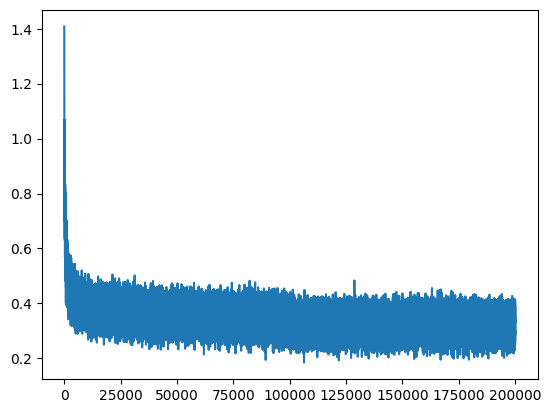

In [114]:
plt.plot(stepi, lossi);

In [116]:
# Loss for the validation dataset
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.1697568893432617


- If training loss is closer to validation loss, then our model could not capture the underlying pattern in the data properly(i.e Underfitting). So we need to make the model more complex by adding more layers or increasing the number of neurons in the hidden layer.

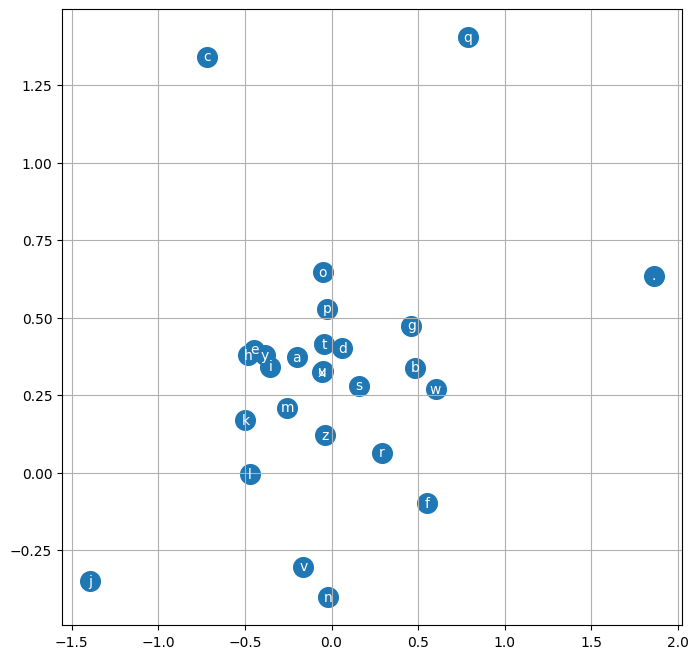

In [117]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

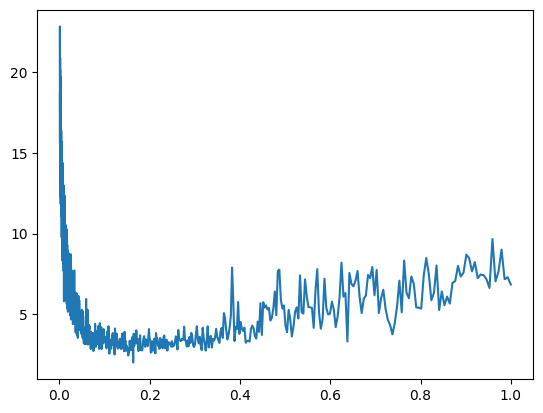

In [77]:
plt.plot(lri, lossi);

- Lowest near `0.1`

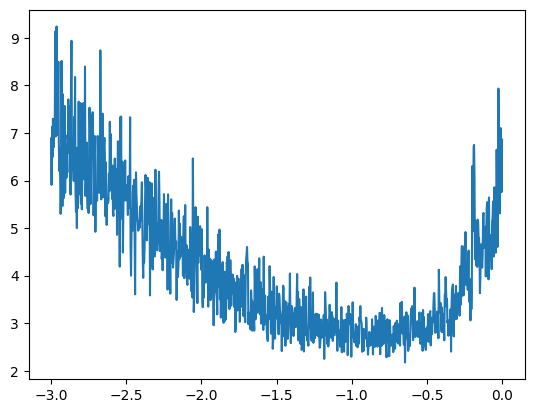

In [79]:
plt.plot(lre, lossi);

- Lowest near `-1.0`, so `lr = 10^-1`

In [118]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
kayah.
see.
med.
rylla.
emmastengrace.
adeerdoelin.
shy.
jen.
eden.
esmanar.
kayzimilara.
nyshabvrichimie.
trick.
weller.
noculfo.
brence.
ryyah.
fael.
yuma.
